# pdf2text-arabic: Visual Step-by-Step Test


### Step 1: Load PDF and View Original Page

This cell simply loads the PDF and displays the full page exactly as it appears in the file.


Loading original page 58 from download/naw.pdf...


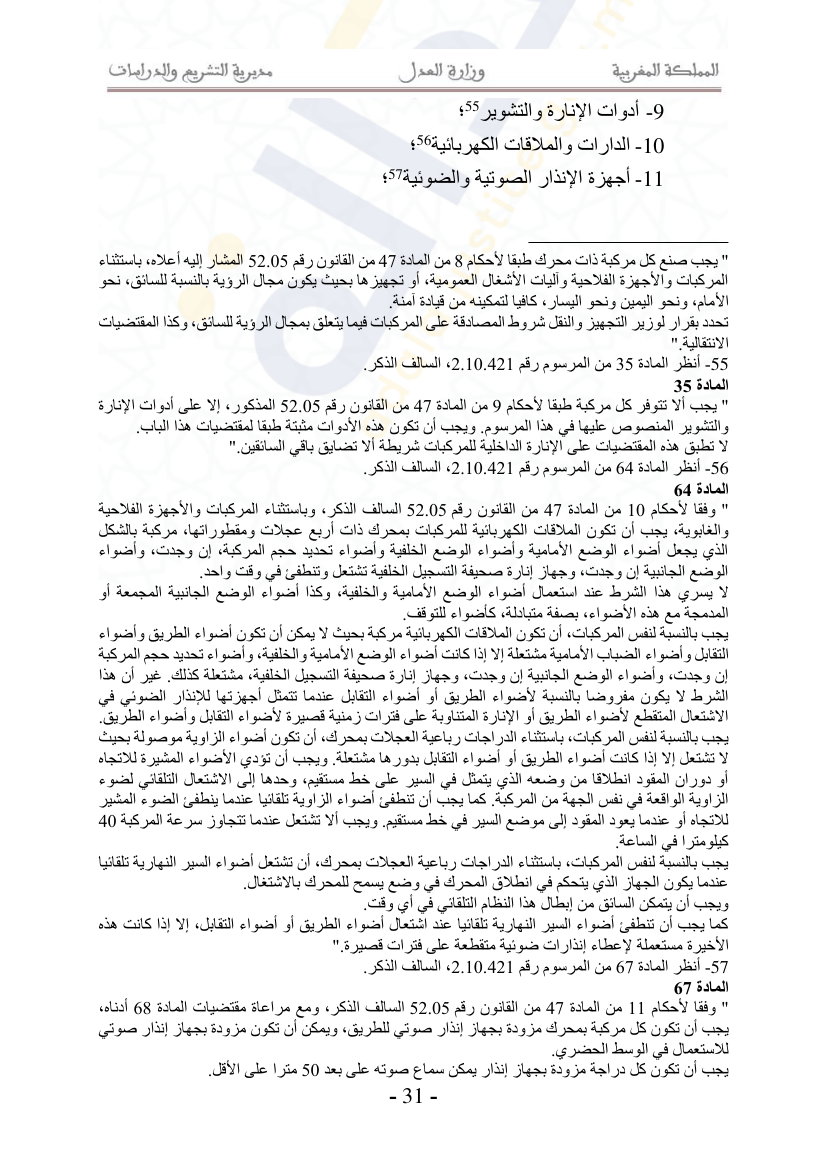

In [19]:
import fitz
from IPython.display import display, Image

download_name = "naw"
pdf_path = f"download/{download_name}.pdf"
doc = fitz.open(pdf_path)
page = doc[30]  # Page 58

print(f"Loading original page 58 from {pdf_path}...")

pix_full = page.get_pixmap(dpi=100)
img_full_path = "full_page_view.png"
pix_full.save(img_full_path)

display(Image(filename=img_full_path))

### Step 2: Apply Surgical Crops and Run OCR

This cell applies the 8% Top / 6% Bottom margins, shows you the result, and then extracts the text using DeepSeek-OCR.


VISUAL PREVIEW (Clipped Area for AI):


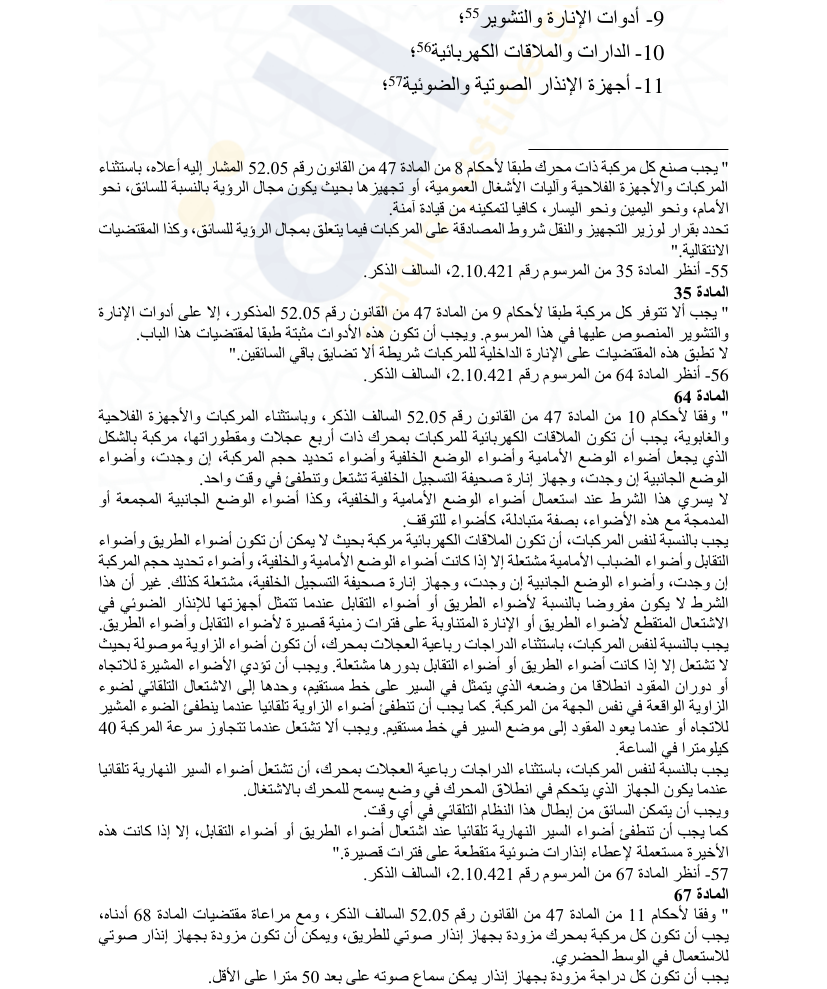


Extracting text via DeepSeek-OCR pipeline...

--- FINAL INTEGRATED OUTPUT ---
-9 أدوات الإنارة والتشوير ؛

-10 الدارات والملاقات الكهربائية ؛

-11 أجهزة الإنذار الصوتية والضوئية ؛

" يجب صنع كل مركبة ذات محرك طبقا لأحكام 8 من المادة 47 من القانون رقم 52.05 المشار إليه أعلاه، باستثناء

المركبات والأجهزة الفلاحية وآليات الأشغال العمومية، أو تجهيزها بحيث يكون مجال الرؤية بالنسبة للسائق، نحو

الأمام، ونحو اليمين ونحو اليسار، كافيا لتمكينه من قيادة آمنة.
تحدد بقرار لوزير التجهيز والنقل شروط المصادقة على المركبات فيما يتعلق بمجال الرؤية للسائق، وكذا المقتضيات

الانتقالية."

- أنظر المادة 35 من المرسوم رقم 2.10.421 ، السالف الذكر.

المادة 35
" يجب ألا تتوفر كل مركبة طبقا لأحكام 9 من المادة 47 من القانون رقم 52.05 المذكور، إلا على أدوات الإنارة

والتشوير المنصوص عليها في هذا المرسوم. ويجب أن تكون هذه الأدوات مثبتة طبقا لمقتضيات هذا الباب.
لا تطبق هذه المقتضيات على الإنارة الداخلية للمركبات شريطة ألا تضايق باقي السائقين."

- أنظر المادة 64 من المرسوم رقم 2.10.421 ، السالف الذكر.

المادة 64
" و

In [20]:
import os
import sys
from pathlib import Path

# Ensure the local library is in the path
sys.path.append(str(Path(os.getcwd())))
from pdf2text_arabic._extract import extract_page

# 1. Show the Cropped Preview (8% Top, 8% Bottom)
h = page.rect.height
w = page.rect.width
crop_top_px = h * 0.08
crop_bottom_px = h * 0.075
clip = fitz.Rect(0, crop_top_px, w, h - crop_bottom_px)

pix_crop = page.get_pixmap(clip=clip, dpi=100)
img_crop_path = "crop_preview.png"
pix_crop.save(img_crop_path)

print("VISUAL PREVIEW (Clipped Area for AI):")
display(Image(filename=img_crop_path))

# 2. Run the actual library extraction
print("\nExtracting text via DeepSeek-OCR pipeline...")
text = extract_page(
    page, on_empty="ocr", crop_top=8, crop_bottom=8, crop_unit="pct", detect_footer=True
)

print("\n--- FINAL INTEGRATED OUTPUT ---")
print(text)

doc.close()